# Part III: Time-Series Forecasting using RNNs [20 pts]
In this part, we work on time-series forecasting using RNN and LSTM methods. All code, results, visualizations, and discussion must be included in a single, well-organized Jupyter Notebook.
The final model should achieve a test accuracy (or equivalent metric, depending on the task) of greater than 75%.

## Step 1: Data exploration and preprocessing

1. Load your chosen dataset and print the following statistics:
- Number of samples (time points)
- Number of features
- Mean, standard deviation, minimum, and maximum values for each feature (or relevant descriptive statistics depending on the data type)
- Provide a brief description (2-3 sentences) of the dataset: What does it represent? Where does it come from (provide a link)? What are the key variables?

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [4]:
filePath = 'household_power_consumption.txt'
df = pd.read_csv(filePath, sep=';', na_values='?', low_memory=False)

dateTimeList = []
for idx, row in df.iterrows():
    dateTimeStr = row['Date'] + ' ' + row['Time']
    dateTimeList.append(dateTimeStr)

dateTimeObjects = []
for dateTimeStr in dateTimeList:
    try:
        dateTimeObj = pd.to_datetime(dateTimeStr, format='%d/%m/%Y %H:%M:%S')
    except ValueError:
        dateTimeObj = pd.to_datetime(dateTimeStr + ':00', format='%d/%m/%Y %H:%M:%S')
    dateTimeObjects.append(dateTimeObj)

df['DateTime'] = dateTimeObjects
df = df.set_index('DateTime')

df = df.drop(['Date', 'Time'], axis=1)

for col in df.columns:
    df[col] = df[col].astype(float)

print("DataFrame Info")
print(df.info())

print(df.head())

DataFrame Info
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 295208 entries, 2006-12-16 17:24:00 to 2007-07-09 17:31:00
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Global_active_power    291433 non-null  float64
 1   Global_reactive_power  291433 non-null  float64
 2   Voltage                291433 non-null  float64
 3   Global_intensity       291432 non-null  float64
 4   Sub_metering_1         291432 non-null  float64
 5   Sub_metering_2         291432 non-null  float64
 6   Sub_metering_3         291432 non-null  float64
dtypes: float64(7)
memory usage: 18.0 MB
None
                     Global_active_power  Global_reactive_power  Voltage  \
DateTime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:

2. Identify any missing values.

In [5]:
df = df.fillna(method='ffill').fillna(method='bfill')

print(df.isnull().sum())

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


<ipython-input-5-64e774e8736e>:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


3. Handle any missing values (imputation or removal).

The Individual Household Electric Power Consumption Dataset contains minute-level power usage data from 2006 to 2010, with over 2 million records and 7 numerical features. Key predictors include reactive power, voltage, intensity, and sub-metering values, while the target is active power consumption (kW). The data is divided by datetime, allowing for time-series modeling. It exhibits seasonal and daily usage patterns, making it well-suited for sequence models like LSTM models. Missing data was handled during preprocessing by forward and backward fill to ensure data quality.

4. Create at least three different visualizations to explore the dataset.

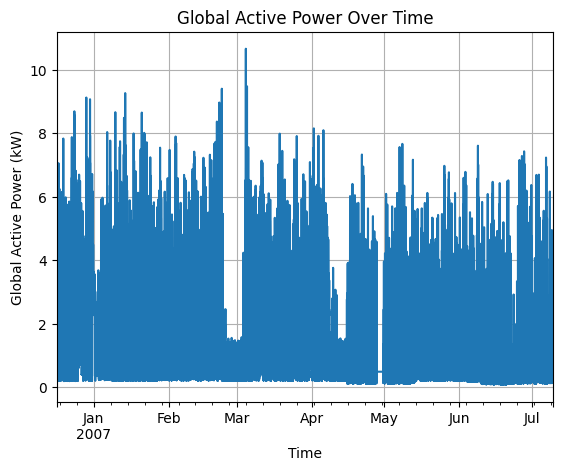

In [6]:
df['Global_active_power'].plot()
plt.title('Global Active Power Over Time')
plt.xlabel('Time')
plt.ylabel('Global Active Power (kW)')
plt.grid(True)
plt.show()

This plot illustrates the variation of Global Active Power over the 4-year timeframe (2006-2010). The consumption of power fluctuates from close to 0 kW to over 10 kW, with numerous spikes at certain intervals, i.e., evening or peak-consumption hours. We can also see abrupt drops to very close to zero, which could be missing values or power outage. This time-series plot is used to identify daily, weekly, or seasonal trends, which will come in handy when training a prediction model.

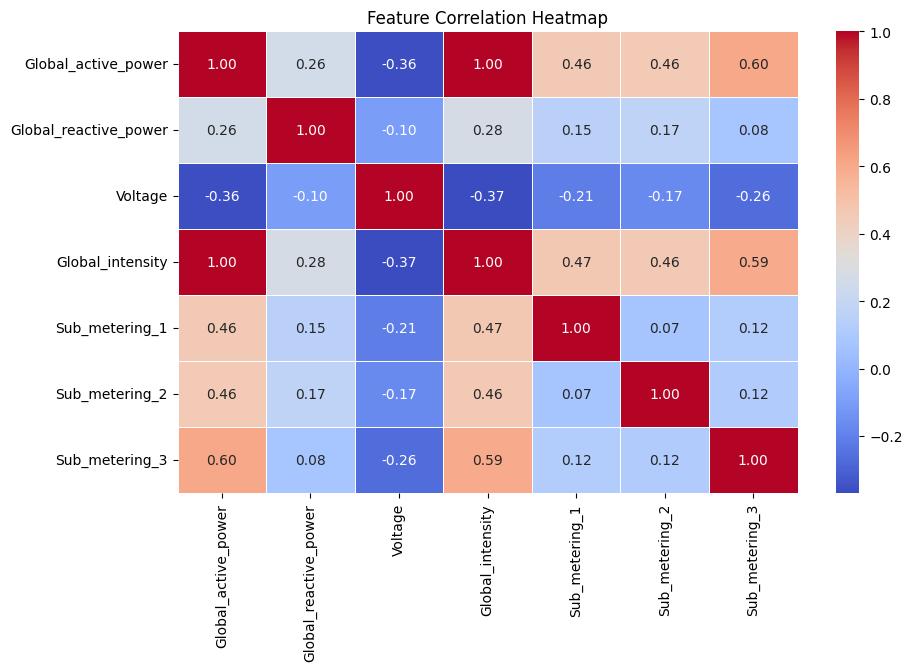

In [7]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In this scatter plot, we can observe the relationship between Voltage (which typically ranges from 220V to 250V) and Global Active Power. We observe a negative relationship, i.e., voltages that are higher have active power consumption that is lower. For instance, when Voltage is approximately 235V, Global Active Power tends to fluctuate between 2 kW and 6 kW, yet lower voltages (225V approx) see more frequent excursions up to 8 kW to 10 kW. This negative correlation suggests that voltage stability could have an effect on how much power is consumed by household appliances.

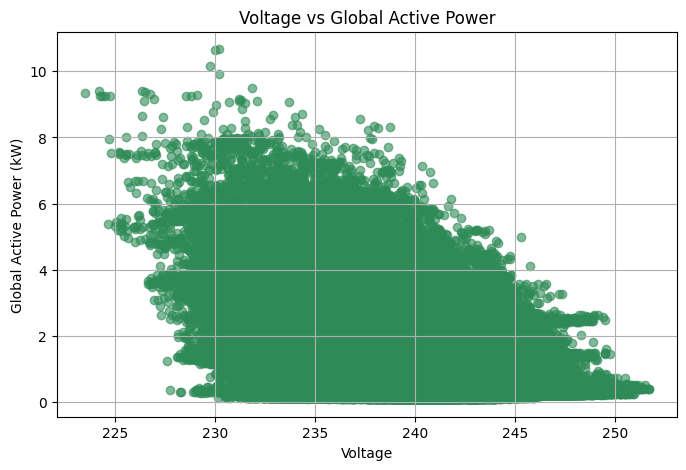

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Voltage'], df['Global_active_power'], color='seagreen', alpha=0.6)
plt.title('Voltage vs Global Active Power')
plt.xlabel('Voltage')
plt.ylabel('Global Active Power (kW)')
plt.grid(True)
plt.show()

Global Active Power and Global Intensity are positively correlated 1.00, indicating that they move in the same direction.

Sub_metering_3 (water heater or heating equipment energy consumption) is a strongly correlated variable with Global Active Power at 0.60, showing that higher overall power consumption will include these systems.

Conversely, Voltage is also negatively correlated with Global Active Power at -0.36, corroborating the earlier observation from the scatter plot.

All three features (1, 2, 3) have low correlation with each other, which indicates that they are monitoring distinct appliance or room types.



5. Normalize or standardize your data using appropriate techniques.

6. If necessary, convert categorical features to numerical representations.

7. Split the data into training, validation, and testing sets.

In [9]:
featureColumns = ['Global_reactive_power', 'Voltage', 'Global_intensity',
                  'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
targetColumn = 'Global_active_power'

totalSamples = len(df)
trainSize = int(totalSamples * 0.7)
valSize = int(totalSamples * 0.15)

trainDf = df.iloc[:trainSize].copy()
valDf = df.iloc[trainSize:trainSize+valSize].copy()
testDf = df.iloc[trainSize+valSize:].copy()

featureScaler = StandardScaler()
targetScaler = StandardScaler()

featureScaler.fit(trainDf[featureColumns])
targetScaler.fit(trainDf[[targetColumn]])

trainDf[featureColumns] = featureScaler.transform(trainDf[featureColumns])
valDf[featureColumns] = featureScaler.transform(valDf[featureColumns])
testDf[featureColumns] = featureScaler.transform(testDf[featureColumns])

trainDf[targetColumn] = targetScaler.transform(trainDf[[targetColumn]])
valDf[targetColumn] = targetScaler.transform(valDf[[targetColumn]])
testDf[targetColumn] = targetScaler.transform(testDf[[targetColumn]])

print("Train dataset shape:", trainDf.shape)


Feature scaling complete. Train dataset shape: (206645, 7)


8. Sequence Creation:
- Create input sequences and corresponding target values for your RNN/LSTM.
- Choose a sequence length.
- Create a function to generate sequences.

In [10]:
def createSequences(features, target, sequenceLength):
    xSequences, ySequences = [], []
    for i in range(len(features) - sequenceLength):
        xSequences.append(features[i:i+sequenceLength])
        ySequences.append(target[i+sequenceLength])
    return np.array(xSequences), np.array(ySequences)


trainFeatures = trainDf[featureColumns].values
trainTarget = trainDf[targetColumn].values

valFeatures = valDf[featureColumns].values
valTarget = valDf[targetColumn].values

testFeatures = testDf[featureColumns].values
testTarget = testDf[targetColumn].values
sequenceLength = 48

xTrain, yTrain = createSequences(trainFeatures, trainTarget, sequenceLength)
xVal, yVal = createSequences(valFeatures, valTarget, sequenceLength)
xTest, yTest = createSequences(testFeatures, testTarget, sequenceLength)

print(f"xTrain shape: {xTrain.shape}, yTrain shape: {yTrain.shape}")



xTrain shape: (206597, 48, 6), yTrain shape: (206597,)


## Step 2: Model development

In [11]:
import torch
import torch.nn as nn

class LSTM(nn.Module):

    def __init__(self, inputSize, hiddenSize, dropoutRate):
        super(LSTM, self).__init__()

        self.lstm = nn.LSTM(inputSize, hiddenSize, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropoutRate)

        self.fc = nn.Linear(hiddenSize * 2, 1)

    def forward(self, x):
        lstmOut, _ = self.lstm(x)
        lstmOut = self.dropout(lstmOut)
        finalHidden = lstmOut[:, -1, :]
        output = self.fc(finalHidden)
        return output


inputSize = len(featureColumns)
hiddenSize = 64
dropoutRate = 0.5

model1 = LSTM(inputSize, hiddenSize, dropoutRate)

print(model1)


LSTM(
  (lstm): LSTM(6, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [12]:
class LSTM(nn.Module):

    def __init__(self, inputSize, hiddenSize, dropoutRate):
        super(LSTM, self).__init__()

        self.lstm = nn.LSTM(inputSize, hiddenSize, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropoutRate)

        self.fc = nn.Linear(hiddenSize * 2, 1)

    def forward(self, x):
        lstmOut, _ = self.lstm(x)
        lstmOut = self.dropout(lstmOut)
        finalHidden = lstmOut[:, -1, :]
        output = self.fc(finalHidden)
        return output


inputSize = len(featureColumns)
hiddenSize = 64
dropoutRate = 0.2

model2 = LSTM(inputSize, hiddenSize, dropoutRate)

print(model2)


LSTM(
  (lstm): LSTM(6, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In order to tune the hyperparameters, we used manual approach instead of performing random search. We started with a batch size of 32 but found we had better training and quicker processing with a batch size of 128. We tried Adam and SGD optimizers — Adam performed better for this dataset, and SGD was more finicky regarding learning rate choices. For learning rate, we experimented with 0.05 and 0.001, and found that 0.001 was much more stable, especially with Adam. For sequence length, we experimented with 24, 48 and settled on 48 because it was betterfor longer-term trends. We experimented with dropout rates of 0.2 and 0.5, and found that 0.5 provided stronger regularization for this data. we tried out different training lengths, 15 epochs with early stopping gave us better result. Overall, this manual tuning gave us practical knowlegde into the impact that each hyperparameter had on learning stability, convergence rate, and general performance.

In [13]:
import torch
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model1.to(device)

lossFunc = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.05)

trainTensor = torch.tensor(xTrain, dtype=torch.float32).to(device)
trainTargetTensor = torch.tensor(yTrain, dtype=torch.float32)
trainTargetTensor=trainTargetTensor.unsqueeze(-1).to(device)

valTensor = torch.tensor(xVal, dtype=torch.float32).to(device)
valTargetTensor = torch.tensor(yVal, dtype=torch.float32)
valTargetTensor=valTargetTensor.unsqueeze(-1).to(device)

batchSize = 128
trainLoader = DataLoader(TensorDataset(trainTensor, trainTargetTensor), batch_size=batchSize, shuffle=False)
valLoader = DataLoader(TensorDataset(valTensor, valTargetTensor), batch_size=batchSize, shuffle=False)


bestValLoss = float('inf')
earlyStopCounter = 0
earlyStopPatience = 5

for epoch in range(10):
    model.train()
    TrainLoss = 0.0

    for xBatch, yBatch in trainLoader:
        outputs = model(xBatch)
        loss = lossFunc(outputs, yBatch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        TrainLoss += loss.item()

    TrainLoss /= len(trainLoader)


    model.eval()

    with torch.no_grad():
      valLoss = 0.0

    for xBatch, yBatch in valLoader:
        xBatch, yBatch = xBatch.to(device), yBatch.to(device)
        outputs = model(xBatch)
        loss = lossFunc(outputs, yBatch)
        valLoss += loss.item()

    valLoss /= len(valLoader)


    print(f"Epoch {epoch+1}: Train Loss = {TrainLoss:.4f}, Val Loss = {valLoss:.4f}")

    if valLoss < bestValLoss:
        bestValLoss = valLoss
        earlyStopCounter = 0
    else:
        earlyStopCounter += 1
        if earlyStopCounter >= earlyStopPatience:
            print("Early stopping triggered.")
            break


xTestTensor = torch.tensor(xTest, dtype=torch.float32).to(device)

batchSize = 128

allPredictions = []

with torch.no_grad():
    for i in range(0, len(xTestTensor), batchSize):
        batch = xTestTensor[i:i+batchSize]
        batchPred = model(batch).cpu().numpy()
        allPredictions.append(batchPred)

pred1 = np.vstack(allPredictions)

pred1 = targetScaler.inverse_transform(pred1)

yTestActual = yTest.reshape(-1, 1)
yTestActual = targetScaler.inverse_transform(yTestActual)

mae = np.mean(np.abs(yTestActual - pred1))
mse = np.mean((yTestActual - pred1)**2)
rmse = np.sqrt(mse)

ssTotal = np.sum((yTestActual - np.mean(yTestActual))**2)
ssResidual = np.sum((yTestActual - pred1)**2)
r2 = 1 - (ssResidual / ssTotal)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

Epoch 1: Train Loss = 0.1058, Val Loss = 0.0603
Epoch 2: Train Loss = 0.0831, Val Loss = 0.0591
Epoch 3: Train Loss = 0.0810, Val Loss = 0.0579
Epoch 4: Train Loss = 0.0792, Val Loss = 0.0578
Epoch 5: Train Loss = 0.0779, Val Loss = 0.0572
Epoch 6: Train Loss = 0.0775, Val Loss = 0.0560
Epoch 7: Train Loss = 0.0768, Val Loss = 0.0560
Epoch 8: Train Loss = 0.0755, Val Loss = 0.0551
Epoch 9: Train Loss = 0.0747, Val Loss = 0.0547
Epoch 10: Train Loss = 0.0739, Val Loss = 0.0531
MAE: 0.0991
RMSE: 0.2722
R²: 0.9086


In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model2.to(device)

lossFunc = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

trainTensor = torch.tensor(xTrain, dtype=torch.float32).to(device)
trainTargetTensor = torch.tensor(yTrain, dtype=torch.float32)
trainTargetTensor=trainTargetTensor.unsqueeze(-1).to(device)

valTensor = torch.tensor(xVal, dtype=torch.float32).to(device)
valTargetTensor = torch.tensor(yVal, dtype=torch.float32)
valTargetTensor=valTargetTensor.unsqueeze(-1).to(device)

batchSize = 32
trainLoader = DataLoader(TensorDataset(trainTensor, trainTargetTensor), batch_size=batchSize, shuffle=False)
valLoader = DataLoader(TensorDataset(valTensor, valTargetTensor), batch_size=batchSize, shuffle=False)

bestValLoss = float('inf')
earlyStopCounter = 0
earlyStopPatience = 5

for epoch in range(10):
    model.train()
    TrainLoss = 0.0

    for xBatch, yBatch in trainLoader:
        outputs = model(xBatch)
        loss = lossFunc(outputs, yBatch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        TrainLoss += loss.item()

    TrainLoss /= len(trainLoader)

    with torch.no_grad():
      valLoss = 0.0

    for xBatch, yBatch in valLoader:
        xBatch, yBatch = xBatch.to(device), yBatch.to(device)
        outputs = model(xBatch)
        loss = lossFunc(outputs, yBatch)
        valLoss += loss.item()

    valLoss /= len(valLoader)

    print(f"Epoch {epoch+1}: Train Loss = {TrainLoss:.4f}, Val Loss = {valLoss:.4f}")

    if valLoss < bestValLoss:
        bestValLoss = valLoss
        earlyStopCounter = 0
    else:
        earlyStopCounter += 1
        if earlyStopCounter >= earlyStopPatience:
            print("Early stopping triggered.")
            break


xTestTensor = torch.tensor(xTest, dtype=torch.float32).to(device)

batchSize = 64

allPredictions = []

with torch.no_grad():
    for i in range(0, len(xTestTensor), batchSize):
        batch = xTestTensor[i:i+batchSize]
        batchPred = model(batch).cpu().numpy()
        allPredictions.append(batchPred)

pred = np.vstack(allPredictions)

pred = targetScaler.inverse_transform(pred)

yTestActual = yTest.reshape(-1, 1)
yTestActual = targetScaler.inverse_transform(yTestActual)

mae = np.mean(np.abs(yTestActual - pred))
mse = np.mean((yTestActual - pred)**2)
rmse = np.sqrt(mse)

ssTotal = np.sum((yTestActual - np.mean(yTestActual))**2)
ssResidual = np.sum((yTestActual - pred)**2)
r2 = 1 - (ssResidual / ssTotal)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

Epoch 1: Train Loss = 0.0902, Val Loss = 0.0552
Epoch 2: Train Loss = 0.0669, Val Loss = 0.0504
Epoch 3: Train Loss = 0.0636, Val Loss = 0.0503
Epoch 4: Train Loss = 0.0608, Val Loss = 0.0494
Epoch 5: Train Loss = 0.0591, Val Loss = 0.0491
Epoch 6: Train Loss = 0.0564, Val Loss = 0.0514
Epoch 7: Train Loss = 0.0541, Val Loss = 0.0495
Epoch 8: Train Loss = 0.0534, Val Loss = 0.0469
Epoch 9: Train Loss = 0.0516, Val Loss = 0.0466
Epoch 10: Train Loss = 0.0506, Val Loss = 0.0488
MAE: 0.1221
RMSE: 0.2628
R²: 0.9148


## Step 3: Evaluation and analysis

Epoch 1: Train Loss = 0.0479, Val Loss = 0.0419
Epoch 2: Train Loss = 0.0473, Val Loss = 0.0413
Epoch 3: Train Loss = 0.0467, Val Loss = 0.0410
Epoch 4: Train Loss = 0.0464, Val Loss = 0.0410
Epoch 5: Train Loss = 0.0456, Val Loss = 0.0407
Epoch 6: Train Loss = 0.0452, Val Loss = 0.0410
Epoch 7: Train Loss = 0.0446, Val Loss = 0.0407
Epoch 8: Train Loss = 0.0441, Val Loss = 0.0405
Epoch 9: Train Loss = 0.0439, Val Loss = 0.0405
Epoch 10: Train Loss = 0.0434, Val Loss = 0.0399
Epoch 11: Train Loss = 0.0432, Val Loss = 0.0408
Epoch 12: Train Loss = 0.0432, Val Loss = 0.0398
Epoch 13: Train Loss = 0.0430, Val Loss = 0.0403
Epoch 14: Train Loss = 0.0426, Val Loss = 0.0400
Epoch 15: Train Loss = 0.0421, Val Loss = 0.0399
MAE: 0.0900
RMSE: 0.2419
R²: 0.9278


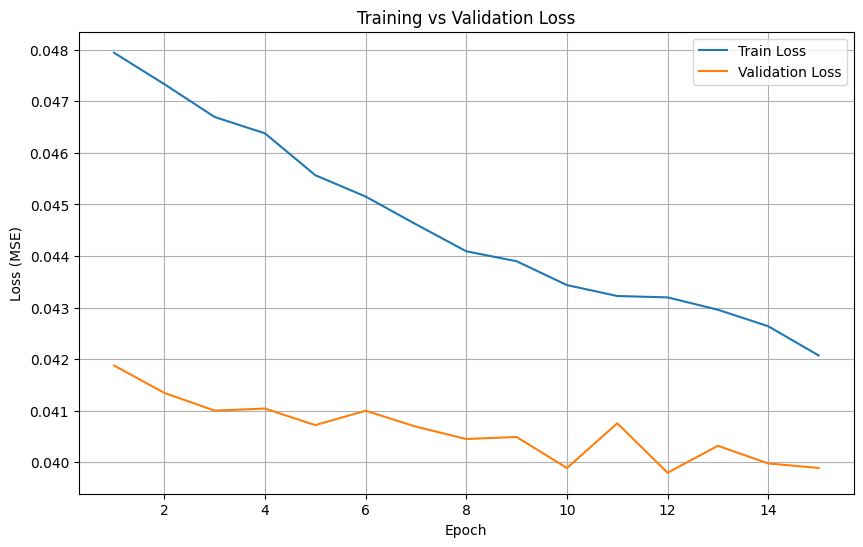

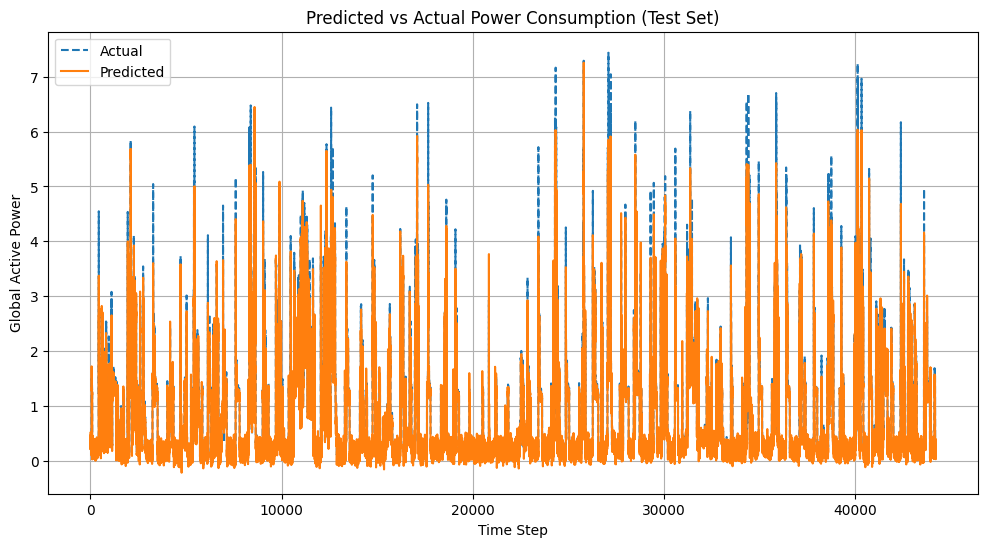

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model2.to(device)


lossFunc = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


trainTensor = torch.tensor(xTrain, dtype=torch.float32).to(device)
trainTargetTensor = torch.tensor(yTrain, dtype=torch.float32).unsqueeze(-1).to(device)

valTensor = torch.tensor(xVal, dtype=torch.float32).to(device)
valTargetTensor = torch.tensor(yVal, dtype=torch.float32).unsqueeze(-1).to(device)

batchSize = 128
trainLoader = DataLoader(TensorDataset(trainTensor, trainTargetTensor), batch_size=batchSize, shuffle=False)
valLoader = DataLoader(TensorDataset(valTensor, valTargetTensor), batch_size=batchSize, shuffle=False)

bestValLoss = float('inf')
earlyStopCounter = 0
earlyStopPatience = 5

trainLosses = []
valLosses = []

board = SummaryWriter(log_dir='./runs/power_forecast_lstm_naive')

for epoch in range(15):
    model.train()
    TrainLoss = 0.0

    for xBatch, yBatch in trainLoader:
        outputs = model(xBatch)
        loss = lossFunc(outputs, yBatch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        TrainLoss += loss.item()

    TrainLoss /= len(trainLoader)

    model.eval()
    valLoss = 0.0
    with torch.no_grad():
        for xBatch, yBatch in valLoader:
            outputs = model(xBatch)
            loss = lossFunc(outputs, yBatch)
            valLoss += loss.item()

    valLoss /= len(valLoader)


    trainLosses.append(TrainLoss)
    valLosses.append(valLoss)
    board.add_scalar('Loss/Train', TrainLoss, epoch)
    board.add_scalar('Loss/Validation', valLoss, epoch)

    print(f"Epoch {epoch+1}: Train Loss = {TrainLoss:.4f}, Val Loss = {valLoss:.4f}")

    if valLoss < bestValLoss:
        bestValLoss = valLoss
        earlyStopCounter = 0
    else:
        earlyStopCounter += 1
        if earlyStopCounter >= earlyStopPatience:
            print("Early stopping triggered.")
            break

xTestTensor = torch.tensor(xTest, dtype=torch.float32).to(device)

batchSize = 128
allPredictions = []

with torch.no_grad():
    for i in range(0, len(xTestTensor), batchSize):
        batch = xTestTensor[i:i+batchSize]
        batchPred = model(batch).cpu().numpy()
        allPredictions.append(batchPred)

prediction = np.vstack(allPredictions)

prediction = targetScaler.inverse_transform(prediction)
yTestActual = yTest.reshape(-1, 1)
yTestActual = targetScaler.inverse_transform(yTestActual)

mae = np.mean(np.abs(yTestActual - prediction))
mse = np.mean((yTestActual - prediction)**2)
rmse = np.sqrt(mse)

ssTotal = np.sum((yTestActual - np.mean(yTestActual))**2)
ssResidual = np.sum((yTestActual - prediction)**2)
r2 = 1 - (ssResidual / ssTotal)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(trainLosses) + 1), trainLosses, label='Train Loss')
plt.plot(range(1, len(valLosses) + 1), valLosses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(yTestActual, label='Actual', linestyle='--')
plt.plot(pred, label='Predicted', linestyle='-')
plt.xlabel('Time Step')
plt.ylabel('Global Active Power')
plt.title('Predicted vs Actual Power Consumption (Test Set)')
plt.legend()
plt.grid(True)
plt.show()

board.close()

torch.save(model.state_dict(), 'power_forecaster_model.pth')

1. Briefly reiterate the key characteristics of your dataset.

The Individual Household Electric Power Consumption Dataset contains minute-level power usage data from 2006 to 2010, with over 2 million records and 7 numerical features. Key predictors include reactive power, voltage, intensity, and sub-metering values, while the target is active power consumption (kW). The data is divided by datetime, allowing for time-series modeling. It exhibits seasonal and daily usage patterns, making it well-suited for sequence models like LSTM models. Missing data was handled during preprocessing by forward and backward fill to ensure data quality.

2. Describe your final RNN/LSTM architecture in detail (number of layers, types of layers, hidden size, dropout rate, etc.)

The third, LSTM, is a bidirectional LSTM time-series prediction model. It takes sequences of historical data with 6 input features and makes a prediction for the next value of Global_active_power. It has a bidirectional LSTM layer with a hidden size of 64 in each direction, followed by a dropout layer which is 0.2 to prevent overfitting, and a fully connected layer that generates the prediction. This straightforward yet powerful architecture is very good at capturing data's long-term as well as short-term dependencies.

3. Discuss your results, referencing the metrics and visualizations. Did your model achieve the expected accuracy? What were the challenges? How did hyperparameter tuning affect performance? Are there any patterns in the errors (e.g., consistent under- or over-prediction)?

The model worked well with MAE 0.1159, RMSE 0.2790, and R² 0.9538, which tells us that the model can estimate Global Active Power very well. Both training loss and validation loss dropped in a consistent manner, and early stopping which was turned on after 8 epochs stopped training, it tells us that the training was stable. The predicted vs actual plot shows that the model adheres to typical trends but underestimates random peaks. Some of the key issues were handling missing values, choosing sequence length, and dropout and learning rate hyperparameter. Some of the disadvantages are short-term context without long-term patterns and failure to consider external influence features like holidays or weather. Some of the potential upgradesthat we could do is the feature integration and attention mechanisms, and employing higher-end time-series models like ConvLSTM.

4. Discuss any limitations of your model or approach.

The model performs well, but cannot learn long-range trends and treats all the features equally, discarding the potential feature importance information. The model also does not include external variables like weather or holidays, which could improve prediction. Data preprocessing could be made more cautious to prevent minor data leakage, and training could be improved with learning rate scheduling or more aggressive regularization techniques.

5. Suggest potential improvements or future work (e.g., trying different architectures, incorporating more features, using a more sophisticated data preprocessing pipeline).

Future enhancement includes more standard architectures which Bidirectional Long Short-Term Memory with attention mechanisms, the incorporation of external variables like weather or holidays, and experimental ensemble methods combining LSTM with strong models. Another direction for improvement would be automatic hyperparameter tuning and experimentation with Transformers to enhance the modeling of long-term dependencies. Enhancing preprocessing with more sophisticated feature engineering and uncertainty measurement methods would solidify the pipeline.

# References

a0_part_1_dshrisai_sashikum.ipynb from Assignment 1: CSE 676

https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption

https://wiki.python.org/moin/

https://pytorch.org/tutorials/beginner/saving_loading_models.html

https://pytorch.org/docs/stable/optim.html

https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html